In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Folder path
folder_path = "./Daten Einzelteile/"

# List of exact file names
files = [
    "Einzelteil_T08.csv", "Einzelteil_T10.csv", "Einzelteil_T14.csv", 
    "Einzelteil_T15.csv", "Einzelteil_T18.csv", "Einzelteil_T19.csv", "Einzelteil_T25.csv"
]

In [13]:
dfs = []

# Leeres Wörterbuch (Dictionary), um die IDs den Städten zuzuordnen
werk_stadt_mapping = {}

for f in files:
    file_path = os.path.join(folder_path, f)

    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep=";", encoding='latin1')
        einzelteil = f.split('_')[1].split('.')[0]

        # Die richtige ID-Spalte finden (Werksnr vs Werksnummer)
        werk_col = 'Werksnr' if 'Werksnr' in df.columns else 'Werksnummer'

        # Die richtige Stadt-Spalte finden (Spalte4 in T08, Werk in den anderen) 
        name_col = 'Spalte4' if 'Spalte4' in df.columns else ('Werk' if 'Werk' in df.columns else None)

        # Das Mapping-Wörterbuch dynamisch aufbauen (Fehlende Werte ignorieren)
        if name_col:
            valid_pairs = df[[werk_col, name_col]].dropna().drop_duplicates()
            for _, row in valid_pairs.iterrows():
                werk_stadt_mapping[row[werk_col]] = row[name_col]

        # Datum formatierung
        df['Produktionsdatum'] = pd.to_datetime(df['Produktionsdatum'], format='mixed', dayfirst=True, errors='coerce')

        # Tabelle bereinigen
        temp_df = pd.DataFrame({
            'Einzelteile': einzelteil,
            'Werk': df[werk_col],
            'Fehlerhaft': df['Fehlerhaft'],
            'Jahr': df['Produktionsdatum'].dt.year
        })
        dfs.append(temp_df)

    else:
        print(f"Warning: Datei {file_path} wurde nicht gefunden!")

# Alle Tabelle zusammenfügen
master_df = pd.concat(dfs, ignore_index=True)

# DAS IST DER TRICK: Wir nutzen das Wörterbuch, um JEDER Zeile die richtige Stadt zuzuweisen
master_df['Werk_Stadt'] = master_df['Werk'].map(werk_stadt_mapping)

fehler_df = master_df[master_df['Fehlerhaft'] == 1]
print(f"Mapping erfolgreich! Gefundene Städte: {list(werk_stadt_mapping.values())}")

Mapping erfolgreich! Gefundene Städte: ['Münster', 'Leibzig', 'Wuppertal', 'Bremen', 'Werder', 'Mannheim', 'Heilbronn', 'Mainz', 'Ulm', 'Düsseldorf', 'Bremen', 'Köln', 'Dresden']


In [14]:
fehler_df.head()

,Einzelteile,Werk,Fehlerhaft,Jahr,Werk_Stadt
13,T08,2045,1,2008,Leibzig
21,T08,2045,1,2008,Leibzig
30,T08,2054,1,2008,Münster
31,T08,2045,1,2012,Leibzig
45,T08,2054,1,2008,Münster


In [19]:
# Fehler pro Werk
fehler_pro_werk = fehler_df.groupby('Werk_Stadt').size()

# Die Werte sortieren, damit das Diagramm besser aussieht (größte Balken zuerst)
fehler_pro_werk = fehler_pro_werk.sort_values(ascending=False)

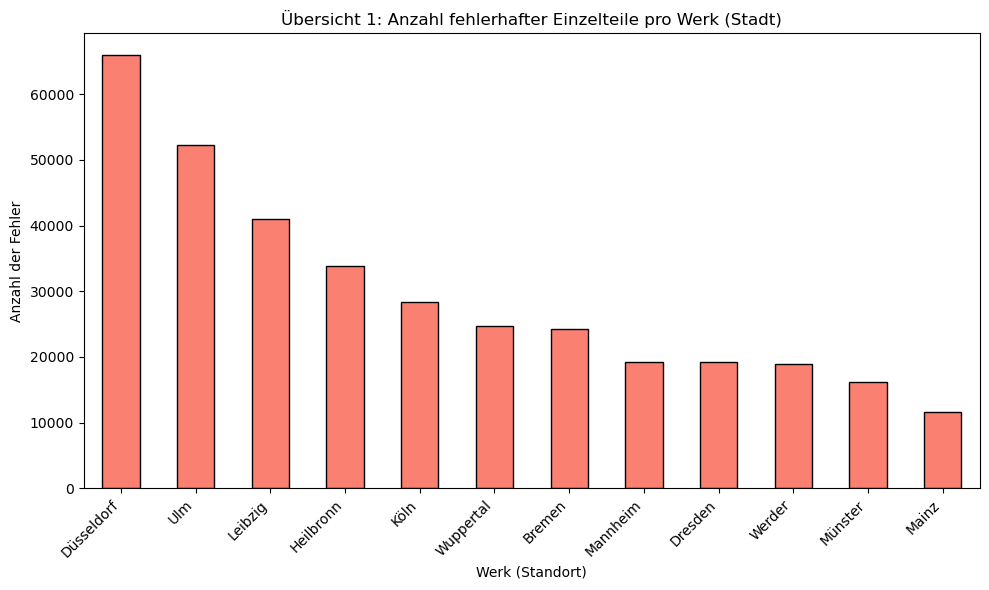

In [20]:
# Übersicht 1: Ein Diagramm mit der Anzahl der fehlerhaften Einzelteile pro STADT
plt.figure(figsize=(10,6))
fehler_pro_werk.plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Übersicht 1: Anzahl fehlerhafter Einzelteile pro Werk (Stadt)')
plt.xlabel('Werk (Standort)')
plt.ylabel('Anzahl der Fehler')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Speichern und auch im Notebook anzeigen
plt.savefig('Uebersicht_1_Fehler_pro_werk.png')
plt.show()

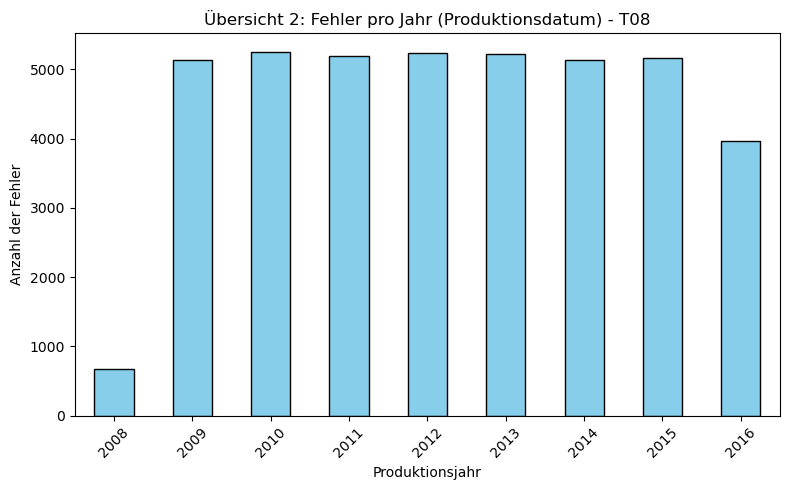

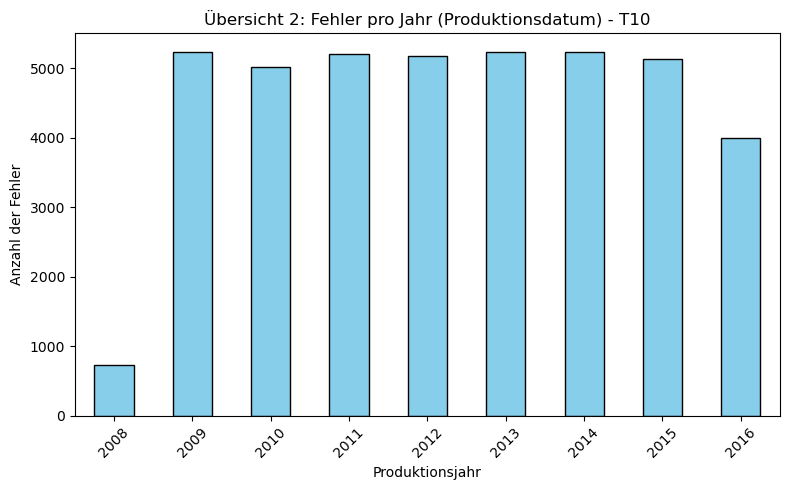

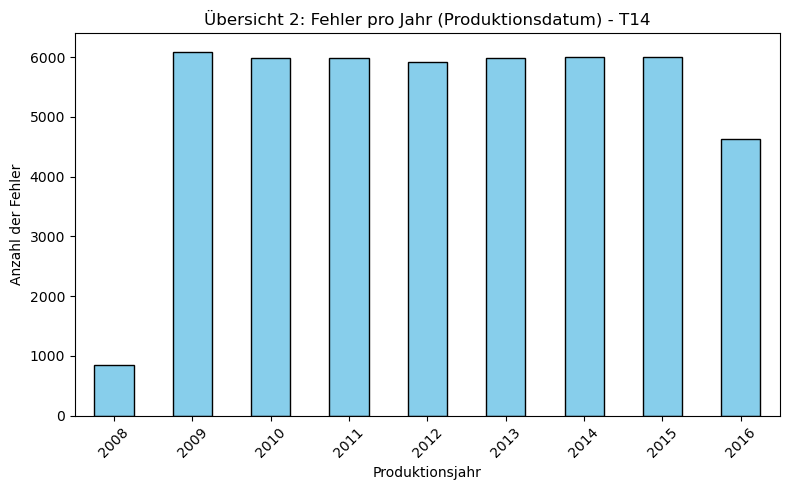

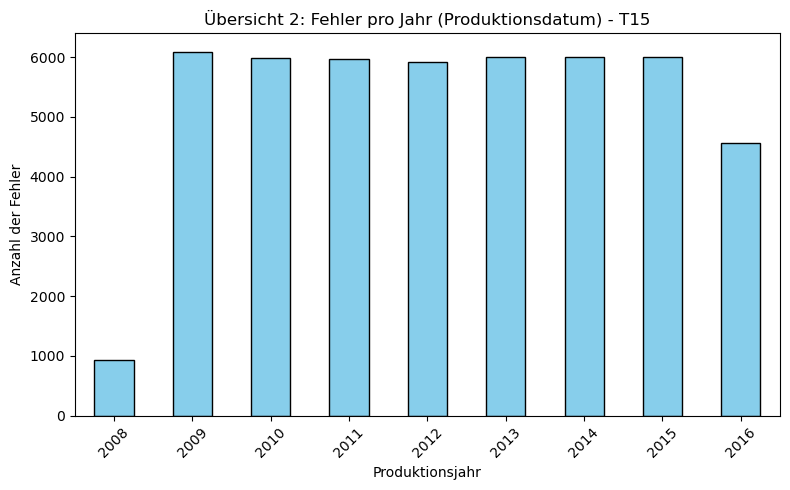

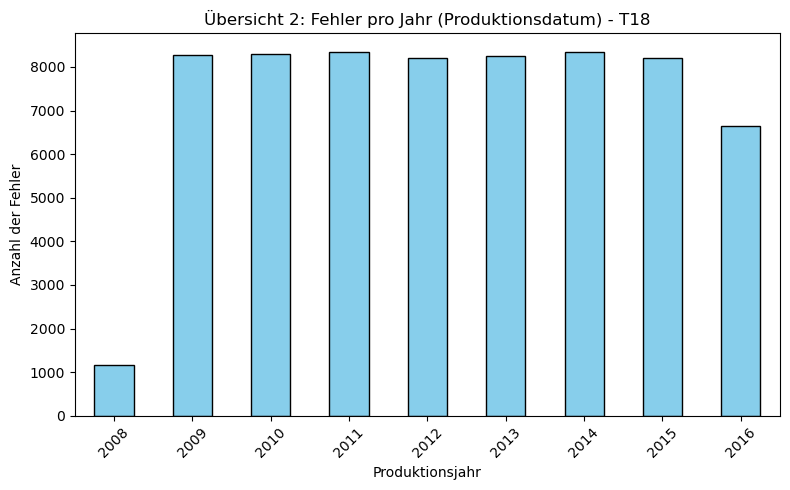

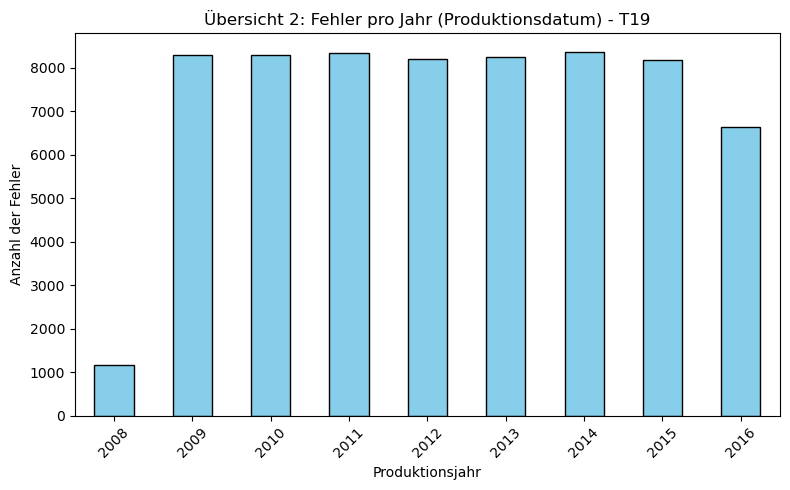

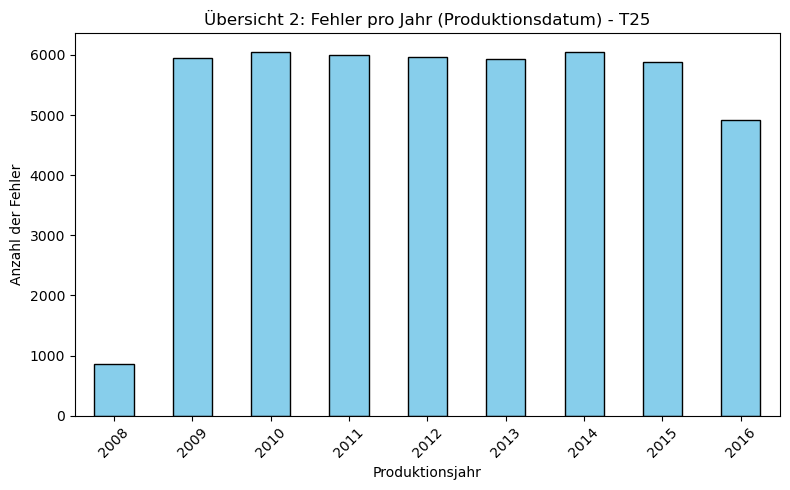

In [22]:
# Übersicht 2: 7 Diagramme über die Anzahl der Fehler pro Jahr für jedes Einzelteil
einzelteile = master_df['Einzelteile'].unique()

for et in einzelteile:
    data_et = fehler_df[fehler_df['Einzelteile'] == et]
    fehler_pro_jahr = data_et.groupby('Jahr').size()
    
    plt.figure(figsize=(8,5))
    fehler_pro_jahr.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title(f'Übersicht 2: Fehler pro Jahr (Produktionsdatum) - {et}')
    plt.xlabel('Produktionsjahr')
    plt.ylabel('Anzahl der Fehler')
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Speichern und im Notebook anzeigen
    plt.savefig(f'Uebersicht_2_Fehler_pro_Jahr_{et}.png')
    plt.show()

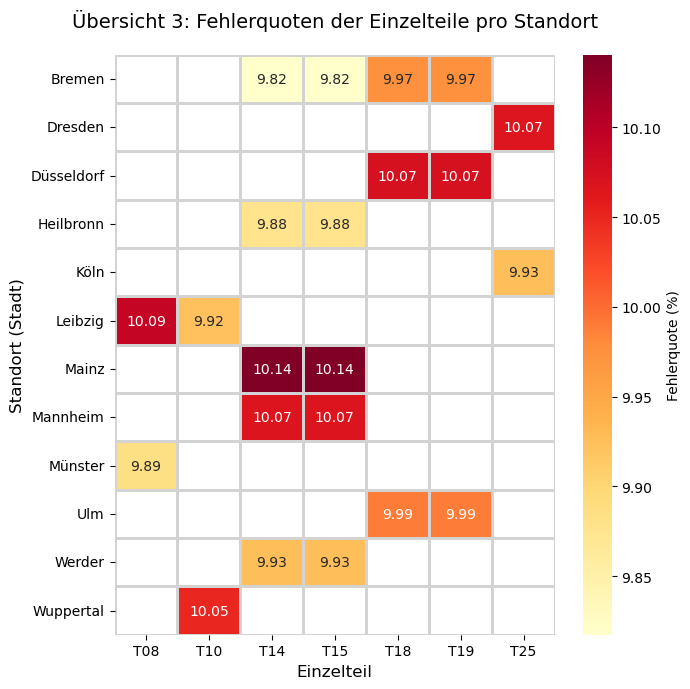

In [26]:
# Übersicht 3: Fehlerquoten in den einzelnen Werken (Städten) in einem Diagramm
import seaborn as sns

quote_df = master_df.groupby(['Einzelteile', 'Werk_Stadt'])['Fehlerhaft'].mean() * 100

heatmap_data = quote_df.unstack(level='Einzelteile')

plt.figure(figsize=(7,7))

# Wir erstellen die Heatmap
# annot=True: Schreibt die genauen %-Zahlen in die Kästchen
# fmt=".2f": Rundet die Zahlen auf 2 Nachkommastellen (z.B. 10.09)
# cmap="YlOrRd": Farbverlauf von Gelb (niedrig) über Orange zu Rot (hoch)
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlOrRd", 
            cbar_kws={'label': 'Fehlerquote (%)'}, linewidths=1, linecolor='lightgrey')

plt.title('Übersicht 3: Fehlerquoten der Einzelteile pro Standort', pad=20, fontsize=14)
plt.xlabel('Einzelteil', fontsize=12)
plt.ylabel('Standort (Stadt)', fontsize=12)
plt.tight_layout()

plt.savefig('Uebersicht_3_Fehlerquoten.png', dpi=300) # dpi=300 sorgt für eine gestochen scharfe Qualität
plt.show()